# Relatório de Análise de Consenso: GPT + Gemini vs Outros

Este notebook foca na avaliação do modelo de **Consenso** (criado a partir da concordância entre GPT e Gemini) em comparação com:
1. Classificaçóes Humanas (Padrão Ouro).
2. Modelos Individuais (GPT 5.4 e Gemini 3.1 Flash).

In [34]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from matplotlib_venn import venn2, venn3
import os

# Configurações de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Caminhos dos arquivos
HUMAN_PATH = "../data/articles_2.json"
GPT_PATH = "../results/gpt-5.4-prod-3-opcoes/result.json"
GEMINI_PATH = "../results/gemini-3-flash-base-2/result.json"
CONSENSUS_PATH = "../results/consensu-gpt-5.4-gemini-flash-3/result.json"

print("Bibliotecas carregadas e caminhos definidos.")

Bibliotecas carregadas e caminhos definidos.


## 1. Carregamento e Consolidação dos Dados

In [35]:
def extract_human_cis(inclusao_val):
    result = {'CI1': False, 'CI2': False, 'CI3': False}
    if not inclusao_val or pd.isna(inclusao_val):
        return result
    inclusao_val = str(inclusao_val).strip().upper()
    for ci in ['CI1', 'CI2', 'CI3']:
        if ci in inclusao_val:
            result[ci] = True
    return result

def load_human_df(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for art in data:
        cis = extract_human_cis(art.get('Inclusão'))
        rows.append({
            'Título': art.get('Título'),
            'Autor': art.get('Autor'),
            'Ano': art.get('Ano'),
            'CI1_Human': cis['CI1'],
            'CI2_Human': cis['CI2'],
            'CI3_Human': cis['CI3']
        })
    return pd.DataFrame(rows)

def load_llm_df(path, suffix):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for res in data:
        meta = res.get('article_metadata', {})
        inc_res = res.get('inclusion_results', [])
        row = {
            'Título': meta.get('title'),
            'Autor': meta.get('author'),
            'Ano': meta.get('year')
        }
        for criterion in ['CI1', 'CI2', 'CI3']:
            decision = "NO"
            for item in inc_res:
                if item.get('criterion', '').upper() == criterion:
                    decision = item.get('decision', 'NO')
                    break
            row[f'{criterion}_{suffix}'] = (decision == 'YES')
        rows.append(row)
    return pd.DataFrame(rows)

df_human = load_human_df(HUMAN_PATH)
df_gpt = load_llm_df(GPT_PATH, 'GPT')
df_gemini = load_llm_df(GEMINI_PATH, 'Gemini')
df_consensus = load_llm_df(CONSENSUS_PATH, 'Consensus')

# Merge total
df_merged = df_human.merge(df_gpt, on=['Título', 'Autor', 'Ano'], how='inner')
df_merged = df_merged.merge(df_gemini, on=['Título', 'Autor', 'Ano'], how='inner')
df_merged = df_merged.merge(df_consensus, on=['Título', 'Autor', 'Ano'], how='inner')

print(f"Total consolidado: {len(df_merged)} artigos")
df_merged.head()

Total consolidado: 100 artigos


,Título,Autor,Ano,CI1_Human,CI2_Human,CI3_Human,CI1_GPT,CI2_GPT,CI3_GPT,CI1_Gemini,CI2_Gemini,CI3_Gemini,CI1_Consensus,CI2_Consensus,CI3_Consensus
0,QAI4ASE: Quantum artificial intelligence for a...,"De Vincentiis, Mirko; Cassano, Fabio; Pagano, ...",2022,False,False,False,False,False,False,False,False,False,False,False,False
1,Software Engineering Methods for Responsible A...,"Islam, Zahoor Ul",2021,True,True,True,True,True,False,True,True,False,True,True,False
2,Digital Twins for Software Engineering Processes,"Kimmel, Robin; Michael, Judith; Wortmann, Andr...",2025,False,False,False,False,False,False,False,False,False,False,False,False
3,Hyacinth macaw: a project-based learning progr...,"Fontão, Awdren; Matsubara, Edson; Mongelli, He...",2023,True,True,True,False,False,False,True,False,False,False,False,False
4,CAIN '22: Proceedings of the 1st International...,NaN,2022,False,False,False,True,False,True,True,False,True,True,False,True


## 2. Estatísticas de Aceitação (Artigos Aceitos)

Nesta seção comparamos a quantidade de artigos que cada método classificou como `YES`.

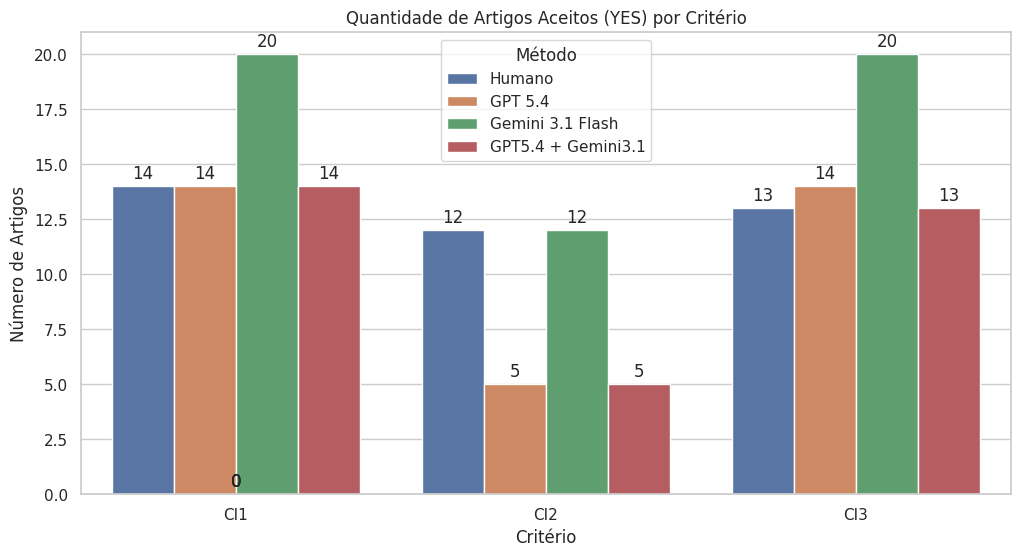

In [36]:
acc_data = []
methods = ['Human', 'GPT', 'Gemini', 'Consensus']
labels = ['Humano', 'GPT 5.4', 'Gemini 3.1 Flash', 'GPT5.4 + Gemini3.1']

for ci in ['CI1', 'CI2', 'CI3']:
    for m, l in zip(methods, labels):
        count = df_merged[f'{ci}_{m}'].sum()
        acc_data.append({'Critério': ci, 'Método': l, 'Aceitos': count})

df_acc_ci = pd.DataFrame(acc_data)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Critério', y='Aceitos', hue='Método', data=df_acc_ci)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title("Quantidade de Artigos Aceitos (YES) por Critério")
plt.ylabel("Número de Artigos")
plt.show()

/tmp/ipykernel_63023/1597877008.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Método', y='Total Aceitos', data=df_total_acc, palette='viridis')


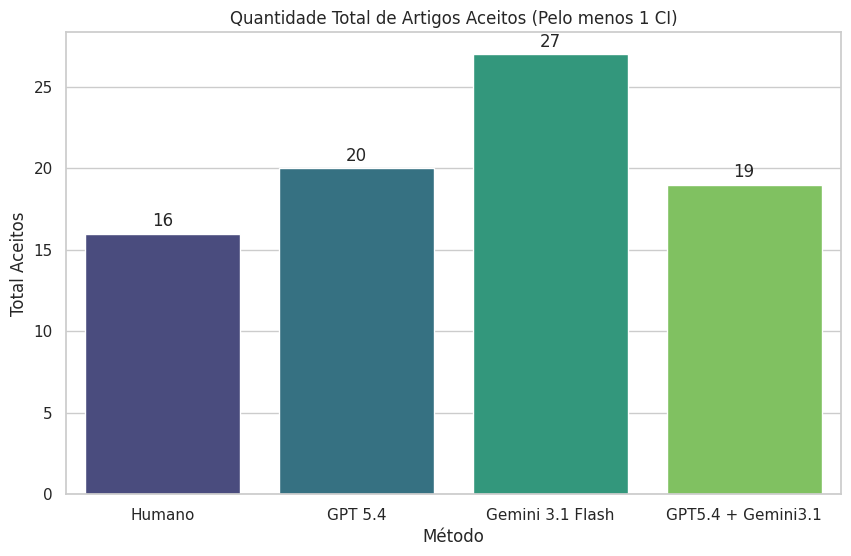

In [37]:
df_merged['Included_Human'] = df_merged[['CI1_Human', 'CI2_Human', 'CI3_Human']].any(axis=1)
df_merged['Included_GPT'] = df_merged[['CI1_GPT', 'CI2_GPT', 'CI3_GPT']].any(axis=1)
df_merged['Included_Gemini'] = df_merged[['CI1_Gemini', 'CI2_Gemini', 'CI3_Gemini']].any(axis=1)
df_merged['Included_Consensus'] = df_merged[['CI1_Consensus', 'CI2_Consensus', 'CI3_Consensus']].any(axis=1)

total_acc = []
cols = ['Included_Human', 'Included_GPT', 'Included_Gemini', 'Included_Consensus']
for c, l in zip(cols, labels):
    total_acc.append({'Método': l, 'Total Aceitos': df_merged[c].sum()})

df_total_acc = pd.DataFrame(total_acc)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Método', y='Total Aceitos', data=df_total_acc, palette='viridis')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title("Quantidade Total de Artigos Aceitos (Pelo menos 1 CI)")
plt.show()

## 3. Consenso vs Humano (Métricas)

Nesta seção, avaliamos o quão bem a estratégia de consenso performa em relação ao humano.

In [38]:
metrics_list = []
for ci in ['CI1', 'CI2', 'CI3']:
    y_true = df_merged[f'{ci}_Human']
    y_pred = df_merged[f'{ci}_Consensus']
    
    metrics_list.append({
        'Critério': ci,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    })

df_metrics_human = pd.DataFrame(metrics_list)
print("Métricas: Consenso vs Humano")
df_metrics_human

Métricas: Consenso vs Humano


,Critério,Accuracy,Precision,Recall,F1-Score
0,CI1,0.90,0.642857,0.642857,0.642857
1,CI2,0.93,1.000000,0.416667,0.588235
2,CI3,0.86,0.461538,0.461538,0.461538


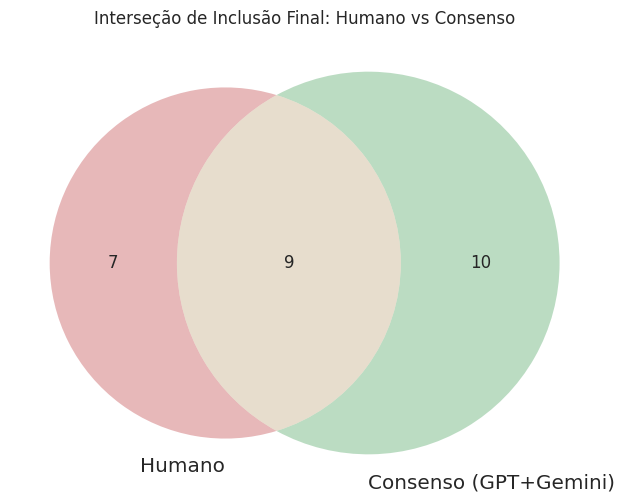

In [39]:
set_h = set(df_merged[df_merged['Included_Human']].index)
set_c = set(df_merged[df_merged['Included_Consensus']].index)

plt.figure(figsize=(8, 6))
venn2([set_h, set_c], ('Humano', 'Consenso (GPT+Gemini)'))
plt.title("Interseção de Inclusão Final: Humano vs Consenso")
plt.show()

## 4. Consenso vs Outros Modelos de IA

Comparando o Consenso com o GPT 5.4 e Gemini 3.1 Flash isoladamente.

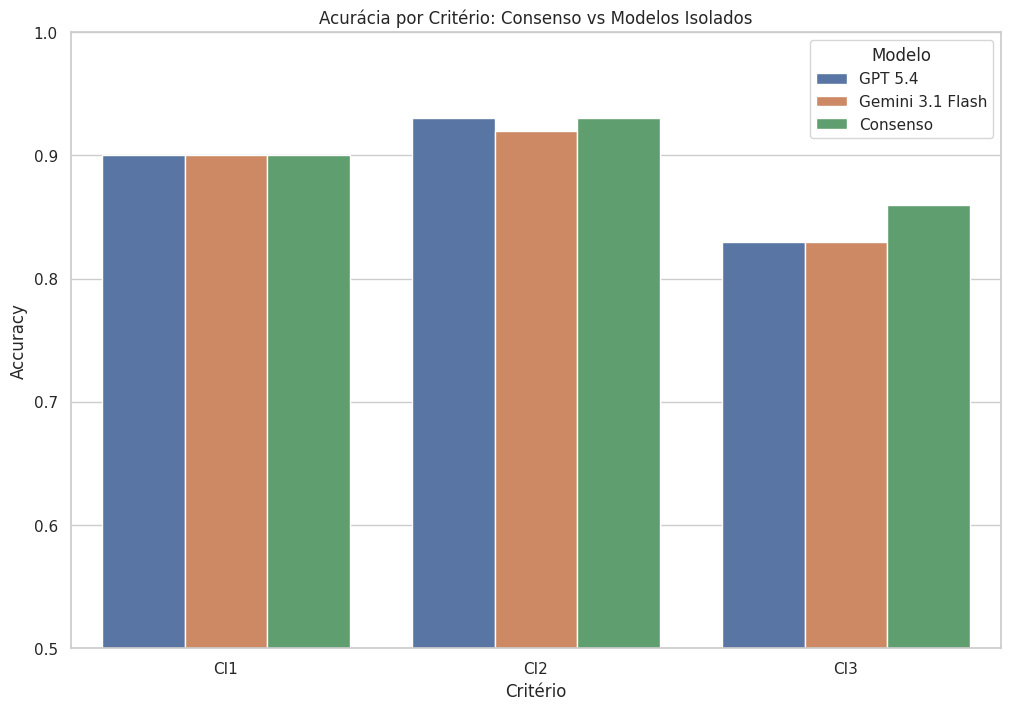

In [40]:
ia_perf = []
for ci in ['CI1', 'CI2', 'CI3']:
    y_h = df_merged[f'{ci}_Human']
    acc_gpt = accuracy_score(y_h, df_merged[f'{ci}_GPT'])
    acc_gem = accuracy_score(y_h, df_merged[f'{ci}_Gemini'])
    acc_con = accuracy_score(y_h, df_merged[f'{ci}_Consensus'])
    
    ia_perf.append({'Critério': ci, 'Modelo': 'GPT 5.4', 'Accuracy': acc_gpt})
    ia_perf.append({'Critério': ci, 'Modelo': 'Gemini 3.1 Flash', 'Accuracy': acc_gem})
    ia_perf.append({'Critério': ci, 'Modelo': 'Consenso', 'Accuracy': acc_con})

df_ia_perf = pd.DataFrame(ia_perf)

sns.barplot(x='Critério', y='Accuracy', hue='Modelo', data=df_ia_perf)
plt.title("Acurácia por Critério: Consenso vs Modelos Isolados")
plt.ylim(0.5, 1.0)
plt.show()

### Interseção de Inclusão: IA vs IA

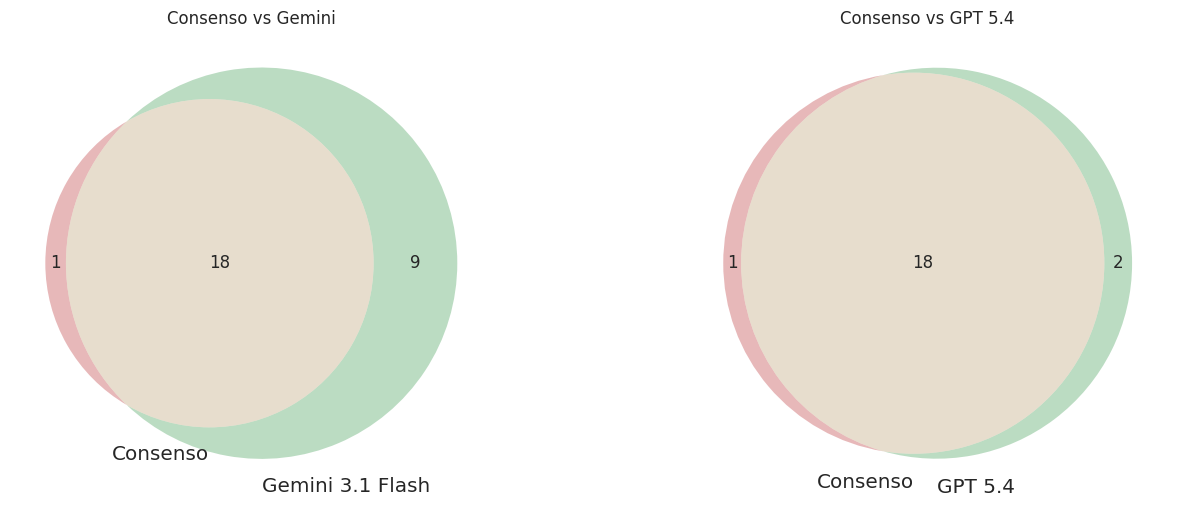

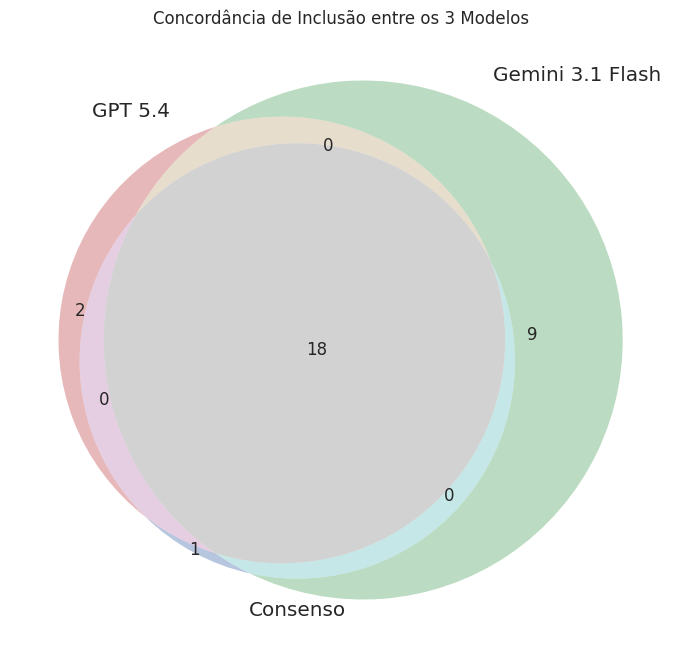

In [41]:
set_gpt = set(df_merged[df_merged['Included_GPT']].index)
set_gemini = set(df_merged[df_merged['Included_Gemini']].index)
set_consensus = set(df_merged[df_merged['Included_Consensus']].index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

venn2([set_consensus, set_gemini], ('Consenso', 'Gemini 3.1 Flash'), ax=axes[0])
axes[0].set_title("Consenso vs Gemini")

venn2([set_consensus, set_gpt], ('Consenso', 'GPT 5.4'), ax=axes[1])
axes[1].set_title("Consenso vs GPT 5.4")

plt.show()

plt.figure(figsize=(10, 8))
venn3([set_gpt, set_gemini, set_consensus], ('GPT 5.4', 'Gemini 3.1 Flash', 'Consenso'))
plt.title("Concordância de Inclusão entre os 3 Modelos")
plt.show()

## 5. Análise de Redução de Ruído (Falsos Positivos)

A principal vantagem do consenso costuma ser a redução de Falsos Positivos.

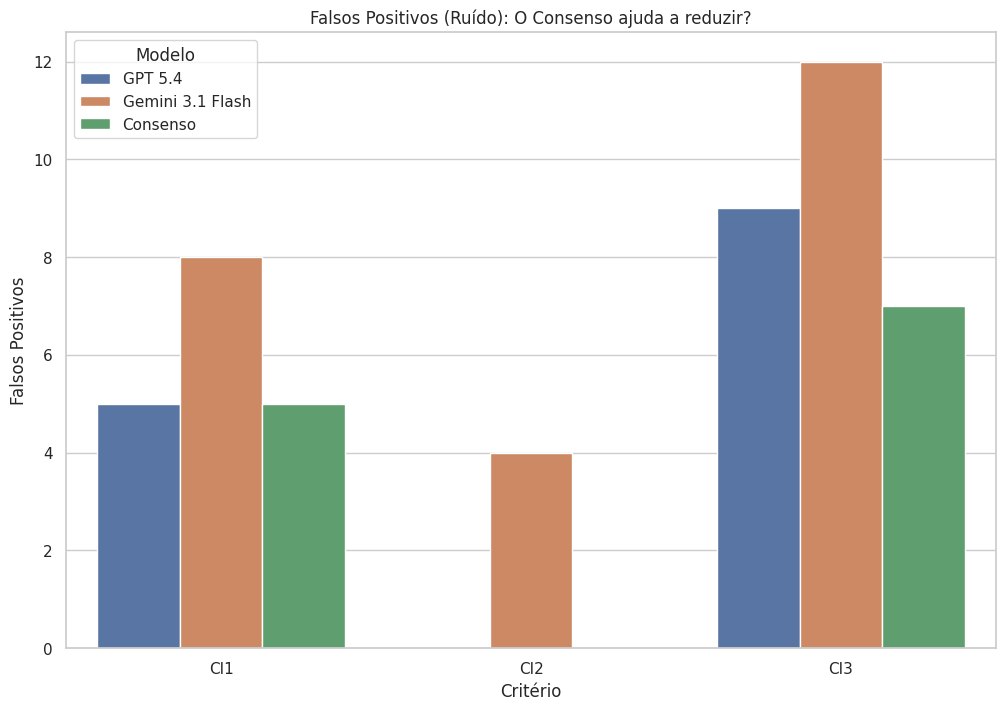

In [42]:
fp_data = []
for ci in ['CI1', 'CI2', 'CI3']:
    y_h = df_merged[f'{ci}_Human']
    fp_gpt = ((y_h == False) & (df_merged[f'{ci}_GPT'] == True)).sum()
    fp_gem = ((y_h == False) & (df_merged[f'{ci}_Gemini'] == True)).sum()
    fp_con = ((y_h == False) & (df_merged[f'{ci}_Consensus'] == True)).sum()
    
    fp_data.append({'Critério': ci, 'Modelo': 'GPT 5.4', 'Falsos Positivos': fp_gpt})
    fp_data.append({'Critério': ci, 'Modelo': 'Gemini 3.1 Flash', 'Falsos Positivos': fp_gem})
    fp_data.append({'Critério': ci, 'Modelo': 'Consenso', 'Falsos Positivos': fp_con})

df_fp = pd.DataFrame(fp_data)
sns.barplot(x='Critério', y='Falsos Positivos', hue='Modelo', data=df_fp)
plt.title("Falsos Positivos (Ruído): O Consenso ajuda a reduzir?")
plt.show()

## Conclusões

- Análise se o modelo de consenso GPT+Gemini é mais conservador.
- Avaliação da eficácia na redução de Falsos Positivos.
- Comparativo de desempenho geral.